In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATA

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


DATA CLEANING

In [ ]:
df.info()

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


/tmp/ipykernel_13775/946555851.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


EDA

1. Churn Distribution

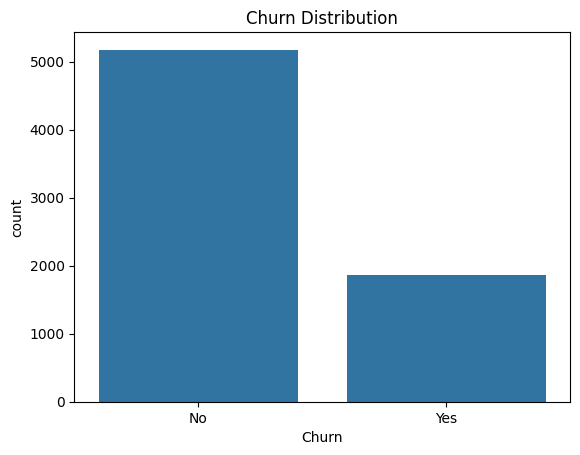

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

2. Gender vs Churn

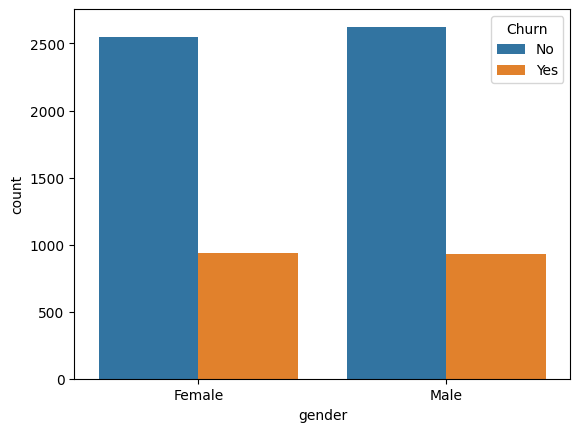

In [ ]:
sns.countplot(x='gender', hue='Churn', data=df)
plt.show()

3. Contract vs Churn

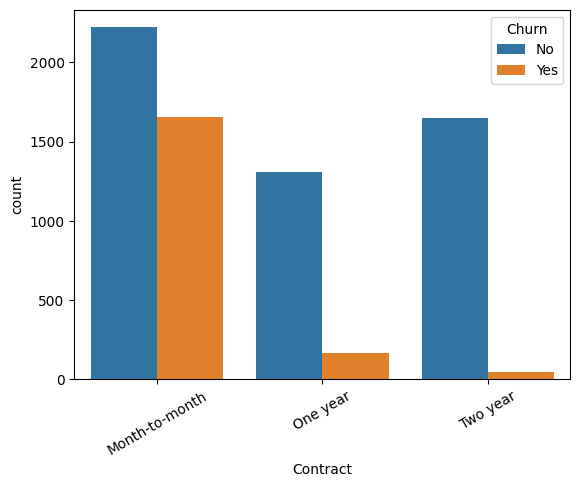

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

4. Monthly Charges Distribution

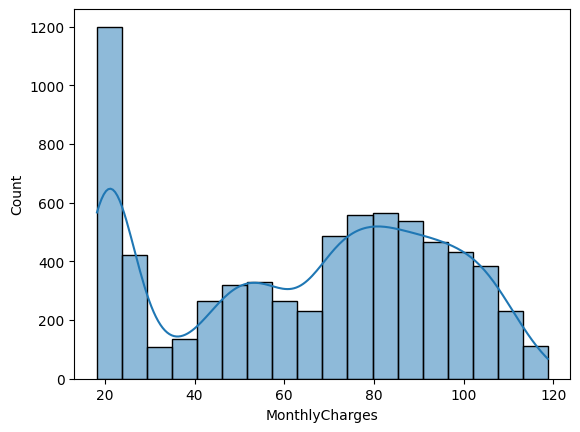

In [ ]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.show()

5. Tenure Distribution

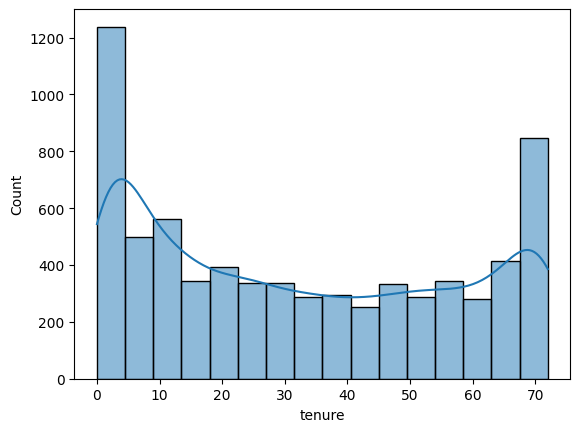

In [ ]:
sns.histplot(df['tenure'], kde=True)
plt.show()

6. Boxplot (Charges vs Churn)

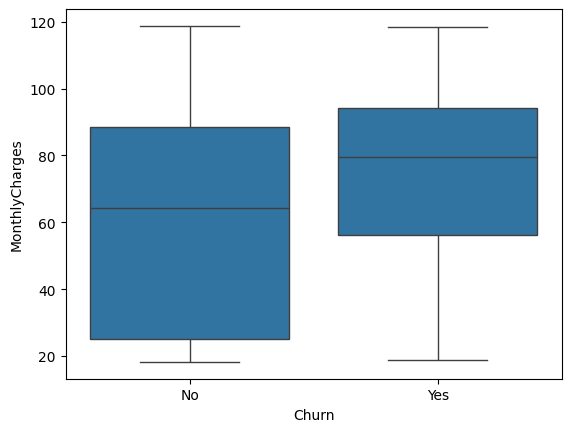

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

7. Boxplot (Tenure vs Churn)

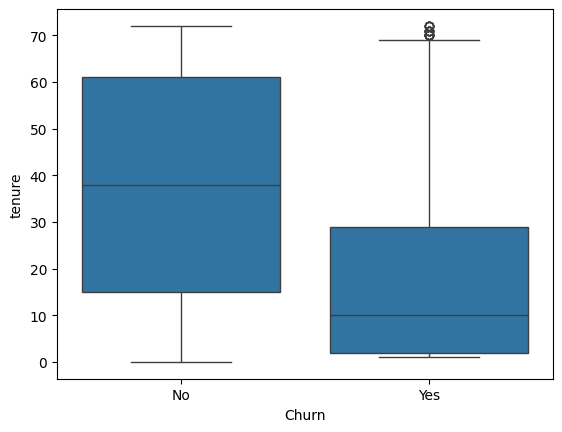

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

8. Correlation Heatmap

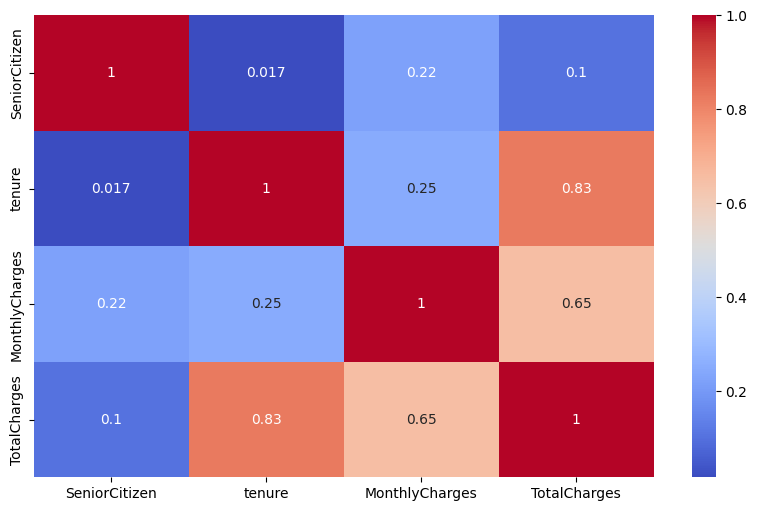

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

DATA PREPROCESSING

In [ ]:
# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

# Convert target variable
df['Churn_Yes'] = df['Churn_Yes'].astype(int)

TRAIN TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

MODEL BUILDING

🔹 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


🔹 Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

🔹 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

MODEL EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score

print("Logistic:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic: 0.8211497515968772
Decision Tree: 0.7203690560681334
Random Forest: 0.7970191625266146


Model Comparison Table 📊

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = ['Logistic', 'Decision Tree', 'Random Forest']

accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

precision = [
    precision_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_rf)
]

recall = [
    recall_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_rf)
]

f1 = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf)
]

results = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic,0.821150,0.685015,0.600536,0.640000
1,Decision Tree,0.720369,0.471390,0.463807,0.467568
2,Random Forest,0.797019,0.666667,0.466488,0.548896


📊 Confusion Matrix

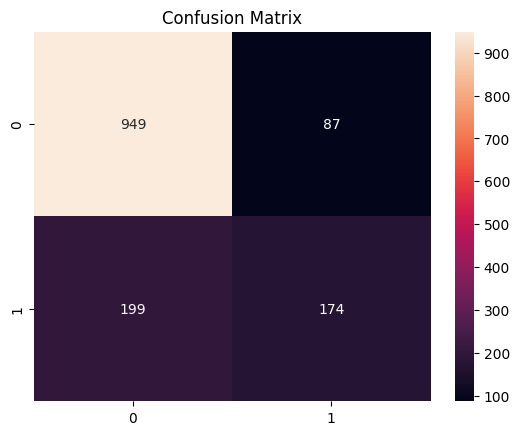

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

📊 ROC Curve

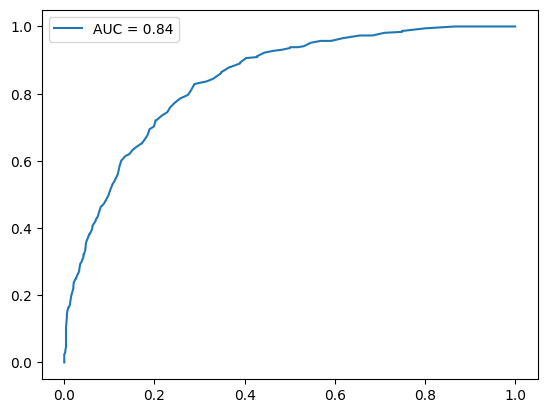

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.legend()
plt.show()

📊 Feature Importance

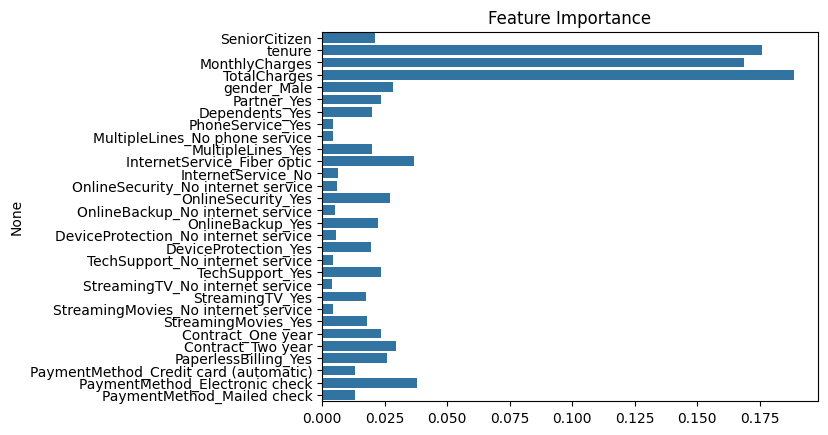

In [ ]:
importances = rf.feature_importances_
features = X.columns

sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average score:", scores.mean())

Cross-validation scores: [0.79772889 0.78921221 0.76508162 0.80184659 0.78977273]
Average score: 0.7887284058648945


Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


Class Imbalance Check

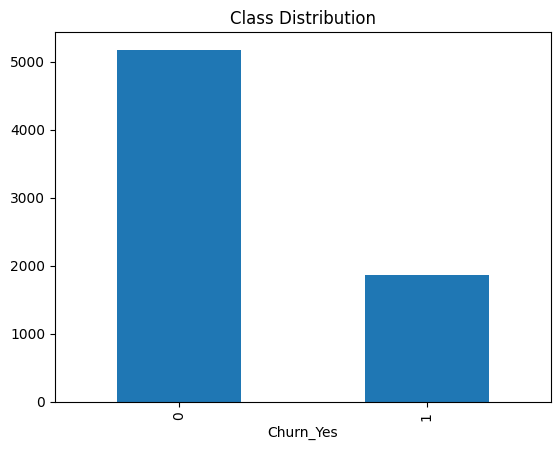

In [ ]:
df['Churn_Yes'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

MORE GRAPHS

1. Churn Percentage Pie Chart

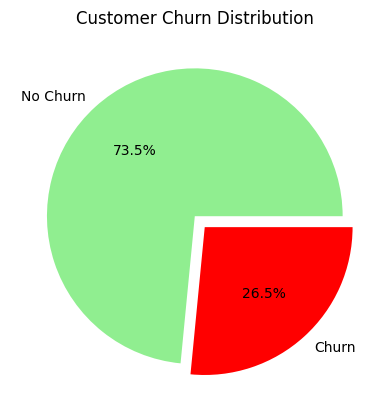

In [ ]:
df['Churn_Yes'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['No Churn','Churn'],
    colors=['lightgreen','red'],
    explode=[0,0.1]
)

plt.title("Customer Churn Distribution")
plt.ylabel('')
plt.show()

2. Count Plot with Percent Labels

/tmp/ipykernel_13775/539162487.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn_Yes', data=df, palette=['green','red'])


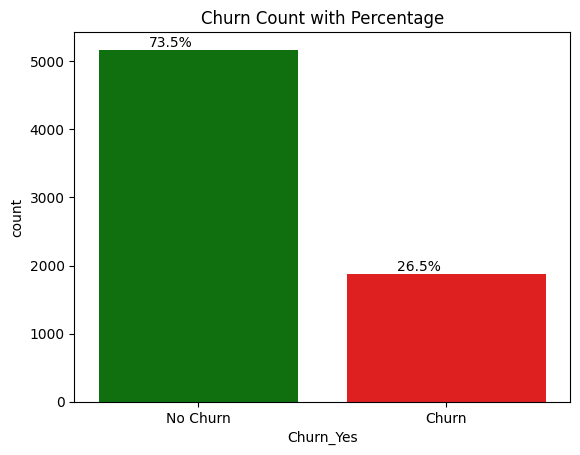

In [ ]:
ax = sns.countplot(x='Churn_Yes', data=df, palette=['green','red'])

total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    ax.annotate(percentage, (p.get_x()+0.2, p.get_height()+50))

plt.xticks([0,1], ['No Churn','Churn'])
plt.title("Churn Count with Percentage")
plt.show()

3. KDE Plot

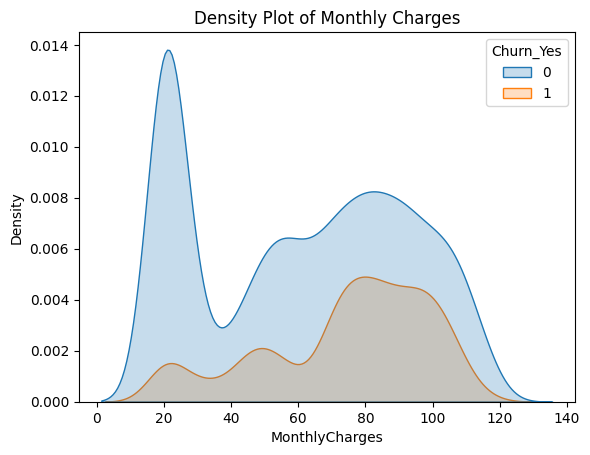

In [ ]:
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn_Yes', fill=True)
plt.title("Density Plot of Monthly Charges")
plt.show()

4. ROC Curve

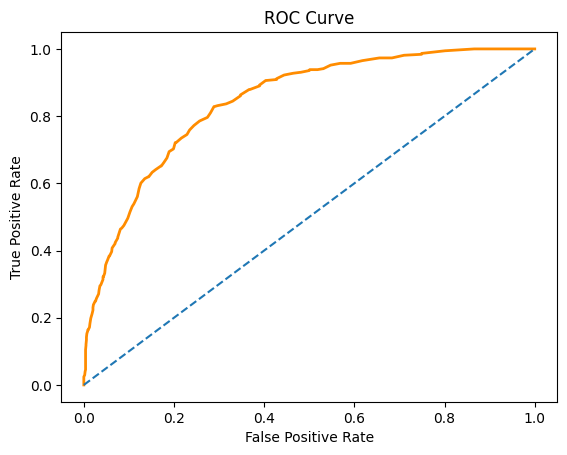

In [ ]:
plt.plot(fpr, tpr, color='darkorange', linewidth=2)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

📊 FINAL MODEL COMPARISON GRAPH

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']

accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

precision = [
    precision_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_rf)
]

recall = [
    recall_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_rf)
]

f1 = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf)
]

Bar Chart

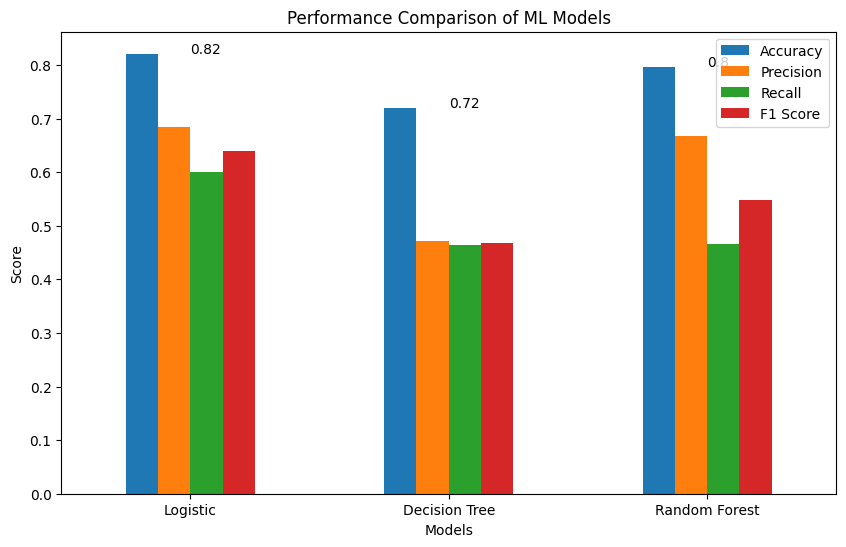

In [ ]:
results.plot(x='Model', kind='bar', figsize=(10,6))

plt.title("Performance Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=0)

for i in range(len(results)):
    plt.text(i, results['Accuracy'][i], round(results['Accuracy'][i],2))

plt.show()

Line Graph

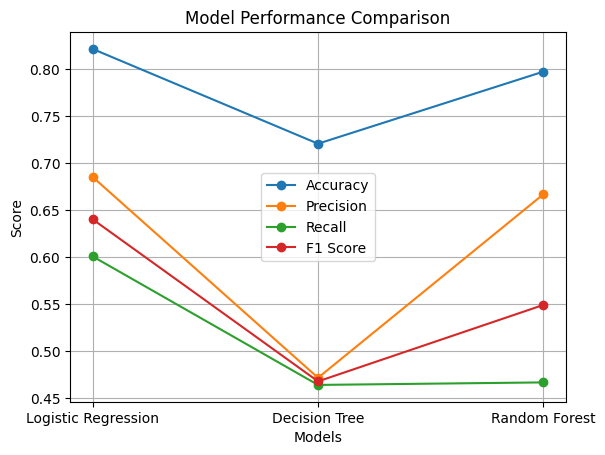

In [ ]:
plt.plot(models, accuracy, marker='o', label='Accuracy')
plt.plot(models, precision, marker='o', label='Precision')
plt.plot(models, recall, marker='o', label='Recall')
plt.plot(models, f1, marker='o', label='F1 Score')

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

FILE FOR TABLEAU

In [ ]:
df.to_csv('cleaned_churn_data.csv', index=False)